In [1]:
import sys
from pathlib import Path

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from ultrasound_tracker.preprocessing import load_video
from ultrasound_tracker.roi import load_rois, draw_rois, extract_roi
from ultrasound_tracker.frangi_detector import FrangiDetector

In [3]:
VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

frames, fps = load_video(str(VIDEO_PATH))
frame0 = frames[0]

rois = load_rois(ROI_PATH)

print("FPS:", fps)
print("Frame shape:", frame0.shape)
print("ROIs:", rois)

Chargé : 2667 frames à 33.3 fps
FPS: 33.341
Frame shape: (562, 706)
ROIs: {'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}


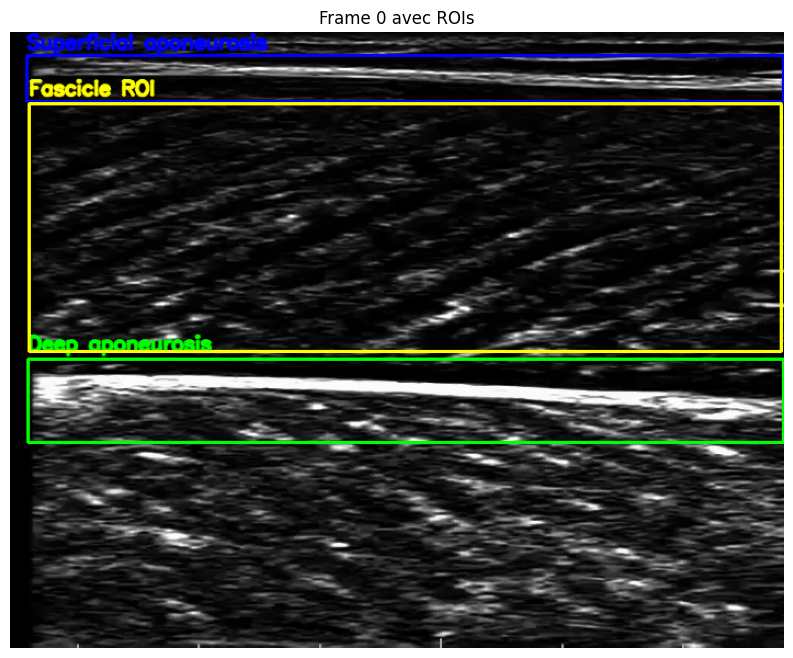

In [4]:
vis = draw_rois(frame0, rois)

plt.figure(figsize=(14, 8))
plt.imshow(vis[..., ::-1])
plt.title("Frame 0 avec ROIs")
plt.axis("off")
plt.show()

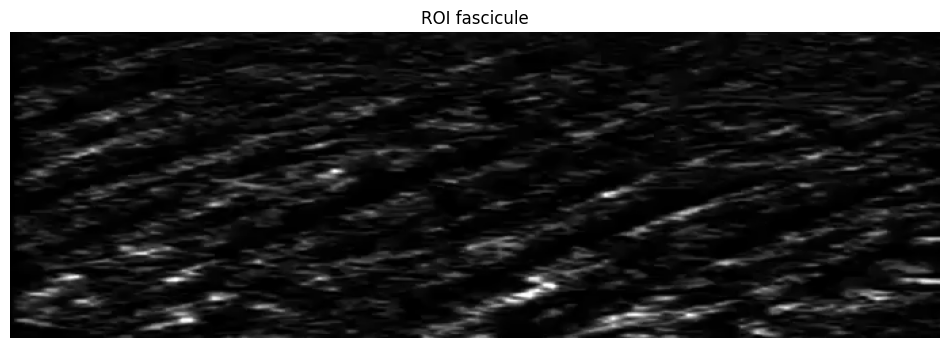

In [5]:
fas_img = extract_roi(frame0, rois["fascicle"])

plt.figure(figsize=(12, 6))
plt.imshow(fas_img, cmap="gray")
plt.title("ROI fascicule")
plt.axis("off")
plt.show()

In [6]:
frangi_detector = FrangiDetector(
    sigmas=(1, 2, 4),
    alpha=0.5,
    beta=15.0,
    black_ridges=False,
    threshold=0.10,
    angle_min=15,
    angle_max=60,
    hough_threshold=20,
    min_line_length=30,
    max_line_gap=15,
)

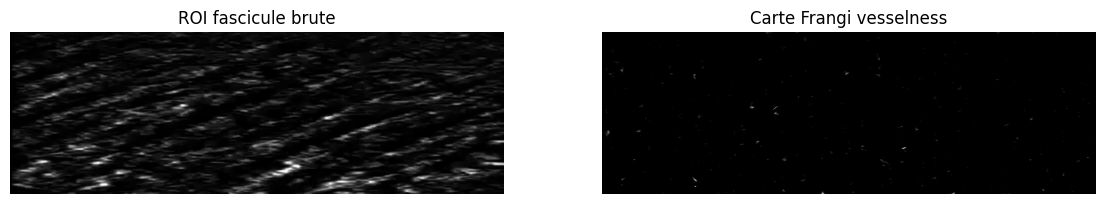

In [7]:
vmap = frangi_detector.get_vesselness_map(fas_img)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(fas_img, cmap="gray")
plt.title("ROI fascicule brute")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(vmap, cmap="gray")
plt.title("Carte Frangi vesselness")
plt.axis("off")

plt.show()

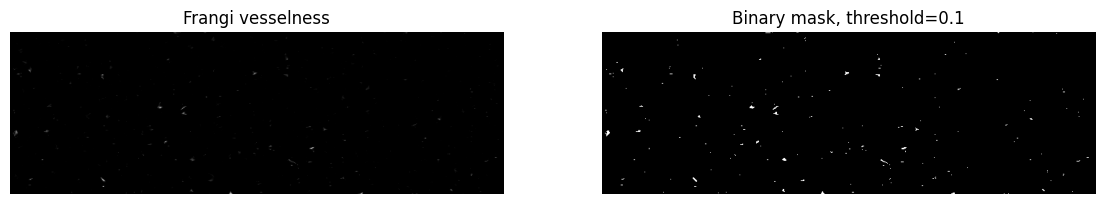

In [8]:
binary = (vmap >= frangi_detector.threshold).astype(np.uint8)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(vmap, cmap="gray")
plt.title("Frangi vesselness")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title(f"Binary mask, threshold={frangi_detector.threshold}")
plt.axis("off")

plt.show()

In [9]:
fas_lines_local, fas_angles, fas_lengths = frangi_detector.detect(fas_img)

print("Nombre de lignes :", None if fas_lines_local is None else len(fas_lines_local))

if fas_angles is not None:
    print("Angles :", fas_angles)
    print("Angle médian :", np.median(fas_angles))
    print("Longueur médiane :", np.median(fas_lengths))

Nombre de lignes : None


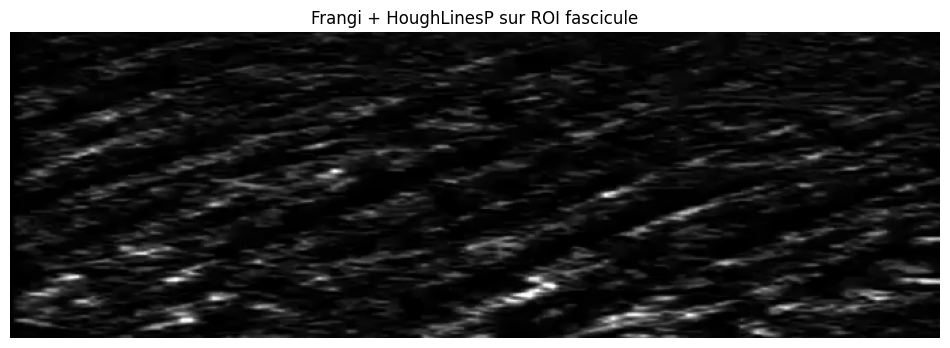

In [10]:
vis_fas = cv2.cvtColor(fas_img, cv2.COLOR_GRAY2BGR)

if fas_lines_local is not None:
    for line, angle in zip(fas_lines_local, fas_angles):
        x1, y1, x2, y2 = line.astype(int)
        cv2.line(vis_fas, (x1, y1), (x2, y2), (0, 255, 255), 2)

        xm = int((x1 + x2) / 2)
        ym = int((y1 + y2) / 2)
        cv2.putText(
            vis_fas,
            f"{angle:.1f}",
            (xm, ym),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (255, 255, 0),
            1,
            cv2.LINE_AA
        )

plt.figure(figsize=(12, 6))
plt.imshow(vis_fas[..., ::-1])
plt.title("Frangi + HoughLinesP sur ROI fascicule")
plt.axis("off")
plt.show()

In [11]:
def offset_lines_to_global(lines, roi):
    if lines is None:
        return None

    x, y, w, h = roi
    out = lines.copy().astype(np.float32)
    out[:, [0, 2]] += x
    out[:, [1, 3]] += y
    return out

fas_lines_global = offset_lines_to_global(fas_lines_local, rois["fascicle"])

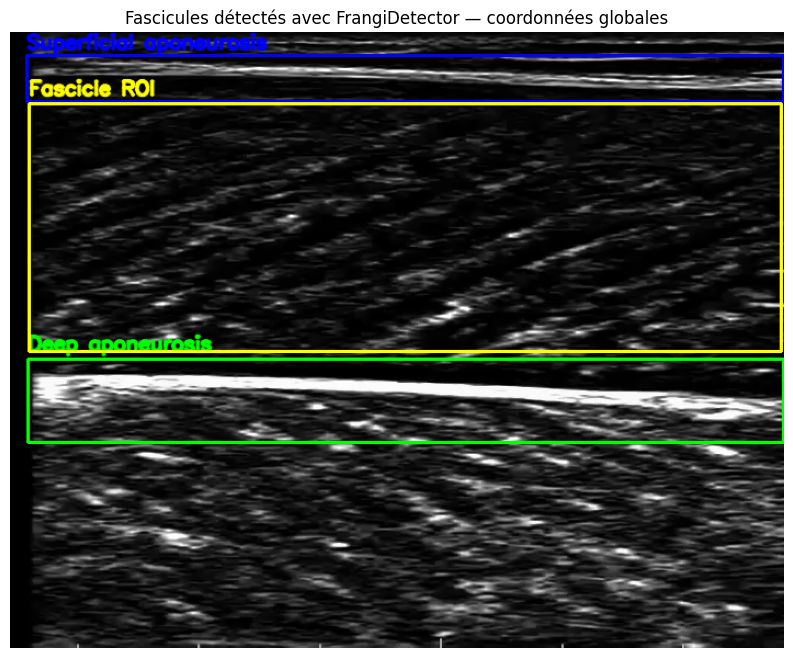

In [12]:
vis_global = draw_rois(frame0, rois)

if fas_lines_global is not None:
    for line, angle in zip(fas_lines_global, fas_angles):
        x1, y1, x2, y2 = line.astype(int)
        cv2.line(vis_global, (x1, y1), (x2, y2), (0, 255, 255), 2)

plt.figure(figsize=(14, 8))
plt.imshow(vis_global[..., ::-1])
plt.title("Fascicules détectés avec FrangiDetector — coordonnées globales")
plt.axis("off")
plt.show()